In [1]:
import torch

from laya.decision import TinyDecisionModel
from laya.transformer import TinyTransformerEncoder
from laya.contextual_rlcd import generate_candidates
from laya.data import build_decision_sequence, encode_batch
from laya.contextual_rlcd import contextual_rlcd_step

In [2]:
encoder = TinyTransformerEncoder(
    vocab_size=100,
    max_seq_len=64,
    d_model=32,
    n_heads=4,
    d_ff=64,
    n_layers=2,
    causal=False,
)
model = TinyDecisionModel(encoder=encoder, d_model=32, decision_hidden_dim=32)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

In [3]:
contexts = [
    build_decision_sequence(
        state_tokens=[
            "customer",
            "charged",
            "twice",
        ],
        question_tokens=[
            "which",
            "department",
        ],
        options=[
            "billing",
            "technical",
            "sales",
        ],
    ),
    build_decision_sequence(
        state_tokens=[
            "app",
            "crashes",
            "after",
            "login",
        ],
        question_tokens=[
            "which",
            "department",
        ],
        options=[
            "billing",
            "technical",
            "sales",
        ],
    ),
    build_decision_sequence(
        state_tokens=[
            "customer",
            "wants",
            "enterprise",
            "pricing",
        ],
        question_tokens=[
            "which",
            "department",
        ],
        options=[
            "billing",
            "technical",
            "sales",
        ],
    ),
]

special_tokens = [
    "[PAD]",
]

vocabulary = special_tokens + sorted(
    {token for sequence in contexts for token in sequence}
)

token_to_id = {token: i for i, token in enumerate(vocabulary)}

token_ids = encode_batch(
    sequences=contexts,
    token_to_id=token_to_id,
)

mask_token_id = token_to_id["[MASK]"]

option_mask = token_ids == mask_token_id

token_ids.shape, option_mask.sum(dim=-1)

(torch.Size([3, 15]), tensor([3, 3, 3]))

In [4]:
true_distributions = torch.tensor(
    [
        [0.80, 0.15, 0.05],
        [0.10, 0.80, 0.10],
        [0.10, 0.20, 0.70],
    ]
)

In [5]:
def sample_outcomes(
    true_distributions: torch.Tensor,
) -> torch.Tensor:
    return torch.multinomial(
        true_distributions,
        num_samples=1,
        replacement=True,
    ).squeeze(-1)

In [6]:
# init - pre train
with torch.no_grad():
    _, probabilities_before = model(
        token_ids=token_ids,
        option_mask=option_mask,
    )

probabilities_before

tensor([[0.3012, 0.3552, 0.3436],
        [0.3214, 0.2521, 0.4265],
        [0.3220, 0.2522, 0.4258]])

In [7]:
# train
n_steps = 5000

loss_history = []
reward_history = []
error_history = []

for step in range(n_steps):
    outcomes = sample_outcomes(true_distributions)

    loss, reward = contextual_rlcd_step(
        model=model,
        optimizer=optimizer,
        token_ids=token_ids,
        option_mask=option_mask,
        outcome=outcomes,
        n_candidates=32,
        exploration_std=0.4,
    )

    loss_history.append(loss)
    reward_history.append(reward)

    with torch.no_grad():
        _, proba = model(token_ids=token_ids, option_mask=option_mask)
        err = (proba - true_distributions).pow(2).mean()
        error_history.append(err)

In [8]:
# post train
with torch.no_grad():
    _, probabilities_after = model(
        token_ids=token_ids,
        option_mask=option_mask,
    )
probabilities_after

tensor([[0.8324, 0.1219, 0.0456],
        [0.0778, 0.8263, 0.0959],
        [0.0573, 0.1704, 0.7723]])

In [9]:
print("True distributions:")
print(true_distributions)

print()

print("Learned distributions:")
print(probabilities_after)

True distributions:
tensor([[0.8000, 0.1500, 0.0500],
        [0.1000, 0.8000, 0.1000],
        [0.1000, 0.2000, 0.7000]])

Learned distributions:
tensor([[0.8324, 0.1219, 0.0456],
        [0.0778, 0.8263, 0.0959],
        [0.0573, 0.1704, 0.7723]])


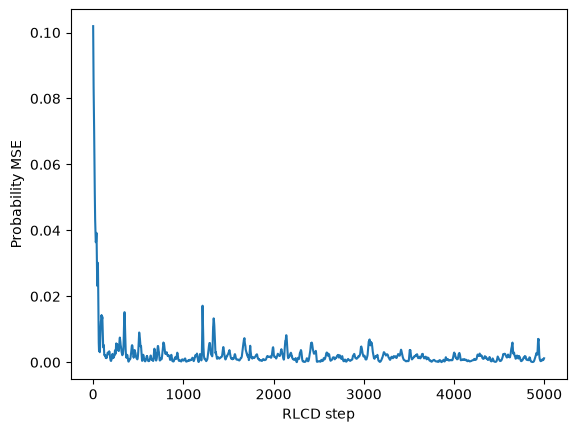

In [10]:
import matplotlib.pyplot as plt

plt.plot(error_history)
plt.xlabel("RLCD step")
plt.ylabel("Probability MSE")
plt.show()